In [2]:
import torch
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import albumentations as A

import urllib.request
import requests
import io

from tqdm import tqdm

In [3]:
class LicensePlateDetection(Dataset):
  def __init__(self, img_dir, labels_dir, transfor=None):
    self.img_dir = img_dir
    self.labels_dir = labels_dir
    self.transfor = transfor
    self.img_files = sorted(os.listdir(img_dir))

  def __len__(self):
    return len(self.img_files)

  def __getitem__(self, idx):
    image_name = self.img_files[idx]
    image_path = os.path.join(self.img_dir, image_name)
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    base_name = os.path.splitext(image_name)[0]
    label_name = os.path.join(self.labels_dir, base_name + '.txt')

    box = [0.0, 0.0, 0.0, 0.0]

    if os.path.exists(label_name):
      with open(label_name, 'r') as f:
        lines = f.readlines()
        if len(lines) > 0:
          first_line = lines[0].strip().split()
          if len(first_line) == 5:
            x_lines = [float(x) for x in first_line[1:]]
            x_center, y_center, w, h = x_lines

            xmin = x_center - (w / 2)
            ymin = y_center - (h / 2)
            xmax = x_center + (w / 2)
            ymax = y_center + (h / 2)

            xmin = max(0.0, min(1.0, xmin))
            ymin = max(0.0, min(1.0, ymin))
            xmax = max(0.0, min(1.0, xmax))
            ymax = max(0.0, min(1.0, ymax))

            box = [xmin, ymin, xmax, ymax]

    if self.transfor:
      augmented = self.transfor(image=image, bboxes=[box])
      image = augmented['image']
      box = augmented['bboxes'][0] if len(augmented['bboxes']) > 0 else [0.0, 0.0, 0.0, 0.0]

    image = torch.tensor(image, dtype=torch.float32).permute(2, 0, 1) / 255.0
    box = torch.tensor(box, dtype=torch.float32)

    return image, box


In [4]:
class PlateDetector(nn.Module):
  def __init__(self):
    super(PlateDetector, self).__init__()

    self.backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    in_features = self.backbone.fc.in_features

    self.backbone.fc = nn.Sequential(
      nn.Linear(in_features, 128),
      nn.ReLU(),
      nn.Linear(128, 4),
      nn.Sigmoid()
    )

  def forward(self, x):
    return self.backbone(x)

In [5]:
def predict_plate(model, img_path, device, output_name='result.jpg'):
    model.eval()
    if not os.path.exists(img_path):
        print(f"Error.")
        return

    orig_img = cv2.imread(img_path)
    h, w, _ = orig_img.shape

    img = cv2.resize(orig_img, (224, 224))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = torch.tensor(img, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0).to(device) / 255.0

    with torch.no_grad():
        preds = model(img).cpu().numpy()[0]

    xmin, ymin, xmax, ymax = preds
    xmin, xmax = int(xmin * w), int(xmax * w)
    ymin, ymax = int(ymin * h), int(ymax * h)

    cv2.rectangle(orig_img, (xmin, ymin), (xmax, ymax), (0, 255, 0), 2)
    cv2.imwrite(output_name, orig_img)

In [6]:
IMG_DIR = 'train/images'
LABEL_DIR = 'train/labels'

In [7]:
os.makedirs(IMG_DIR, exist_ok=True)
os.makedirs(LABEL_DIR, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

train_transform = A.Compose([
    A.Resize(224, 224),
    A.HorizontalFlip(p=0.5),
], bbox_params=A.BboxParams(format='albumentations', label_fields=[]))

dataset = LicensePlateDetection(img_dir=IMG_DIR, labels_dir=LABEL_DIR, transfor=train_transform)
train_loader = DataLoader(dataset, batch_size=32, shuffle=True)

In [8]:
model = PlateDetector().to(device)
criterion = nn.SmoothL1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

epochs = 6
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", unit="batch")
    for images, boxes in pbar:
        images, boxes = images.to(device), boxes.to(device)
        outputs = model(images)
        loss = criterion(outputs, boxes)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)

        pbar.set_postfix({"batch_loss": f"{loss.item():.4f}"})

    print(f"Epoch [{epoch+1}], Loss: {running_loss / len(dataset):.4f}")


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 167MB/s]
Epoch 1/6: 100%|██████████| 641/641 [04:34<00:00,  2.33batch/s, batch_loss=0.0046]


Epoch [1], Loss: 0.0028


Epoch 2/6: 100%|██████████| 641/641 [04:27<00:00,  2.39batch/s, batch_loss=0.0023]


Epoch [2], Loss: 0.0016


...

Epoch [4], Loss: 0.0010


Epoch 5/6: 100%|██████████| 641/641 [04:21<00:00,  2.46batch/s, batch_loss=0.0003]


Epoch [5], Loss: 0.0009


Epoch 6/6: 100%|██████████| 641/641 [04:18<00:00,  2.48batch/s, batch_loss=0.0009]

Epoch [6], Loss: 0.0008


In [12]:
# torch.save(model.state_dict(), 'plate_detector.pth')
predict_plate(model, os.path.join(IMG_DIR, '3.jpg'), device)

In [18]:
def predict_by_url(model, url, device, output_name='url_result.jpg'):
    model.eval()

    headers = {'User-Agent': 'Mozilla/5.0'}
    response = requests.get(url, headers=headers, timeout=10)

    img_array = np.asarray(bytearray(response.content), dtype=np.uint8)
    orig_img = cv2.imdecode(img_array, cv2.IMREAD_COLOR)

    h, w, _ = orig_img.shape

    img = cv2.resize(orig_img, (224, 224))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = torch.tensor(img, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0).to(device) / 255.0

    with torch.no_grad():
        preds = model(img).cpu().numpy()[0]

    xmin, ymin, xmax, ymax = preds

    xmin = int(xmin * w)
    ymin = int(ymin * h)
    xmax = int(xmax * w)
    ymax = int(ymax * h)

    xmin = max(0, min(xmin, w))
    ymin = max(0, min(ymin, h))
    xmax = max(0, min(xmax, w))
    ymax = max(0, min(ymax, h))

    cv2.rectangle(orig_img, (xmin, ymin), (xmax, ymax), (0, 255, 0), 3)
    cv2.imwrite(output_name, orig_img)

    plt.imshow(cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

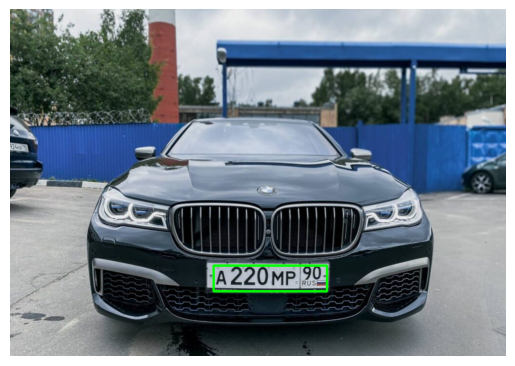

In [23]:
car_url = "https://specznak77.ru/wp-content/uploads/2025/07/blog_17_1-1024x716.jpg"
predict_by_url(model, car_url, device, output_name='detected_plate.jpg')

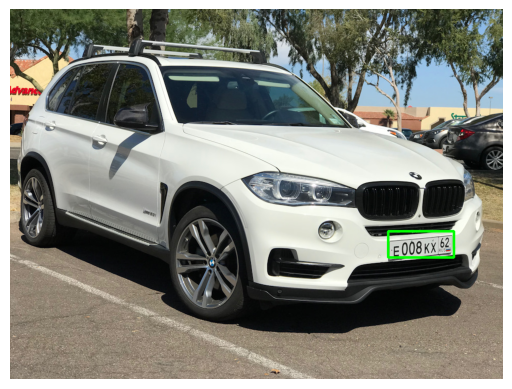

In [22]:
car_url = "https://a1.drive-data.ru/2647595s-960.jpg"
predict_by_url(model, car_url, device, output_name='detected_plate2.jpg')

In [24]:
torch.save(model.state_dict(), 'plate_detector.pth')

In [25]:
model = PlateDetector()

In [28]:
torch.save(model, 'complete_model.pth')